This notebook summarizes statistics for replicate correlation among all strains

In [7]:
import pandas as pd

In [8]:
import pandas as pd
import glob
import os

base_dir = "/Users/annasve/Desktop/article_data/output/replicate_correlation"

files = glob.glob(os.path.join(base_dir, "**/*.xlsx"), recursive=True)

# remove temporary excel files
files = [f for f in files if not os.path.basename(f).startswith("~$")]

print(f"{len(files)} files found")

dfs = []

for f in files:
    try:
        df = pd.read_excel(f, engine="openpyxl")
        df["source_file"] = os.path.basename(f)
        dfs.append(df)
    except Exception as e:
        print(f"Skipping {f}: {e}")

combined = pd.concat(dfs, ignore_index=True)

print(combined.head())
print(combined.shape)

28 files found
      Strain media  replicates  mean_corr  min_corr  \
0  NBC_01392  DNPM           2   0.993165  0.993165   
1  NBC_01392  ISP2           2   0.936986  0.936986   
2  NBC_01392    MA           2   0.990489  0.990489   
3  NBC_01392  SoyM           2   0.989094  0.989094   
4  NBC_01392   TSB           2   0.989588  0.989588   

                        source_file  
0  NBC_01392_replicate_quality.xlsx  
1  NBC_01392_replicate_quality.xlsx  
2  NBC_01392_replicate_quality.xlsx  
3  NBC_01392_replicate_quality.xlsx  
4  NBC_01392_replicate_quality.xlsx  
(224, 6)


In [9]:
summary = {
    "n_strains": combined["Strain"].nunique(),
    "n_conditions": combined.shape[0],
    "mean_corr_mean": combined["mean_corr"].mean(),
    "mean_corr_median": combined["mean_corr"].median(),
    "mean_corr_min": combined["mean_corr"].min(),
    "mean_corr_max": combined["mean_corr"].max(),
    "mean_corr_std": combined["mean_corr"].std()
}

summary = pd.Series(summary)

print(summary)

n_strains            28.000000
n_conditions        224.000000
mean_corr_mean        0.932572
mean_corr_median      0.951421
mean_corr_min         0.656868
mean_corr_max         0.994367
mean_corr_std         0.060903
dtype: float64


In [10]:
media_summary = (
    combined
    .groupby("media")["mean_corr"]
    .agg(["mean","median","min","max","std","count"])
    .sort_values("mean", ascending=False)
)

print(media_summary)

           mean    median       min       max       std  count
media                                                         
DNPM   0.946424  0.961979  0.829274  0.993467  0.044106     28
MA     0.945799  0.951118  0.792006  0.994367  0.045955     28
malt   0.938772  0.957725  0.730849  0.991353  0.061728     28
SoyM   0.936048  0.951750  0.819525  0.991755  0.050321     28
TSB    0.928529  0.952222  0.656868  0.989588  0.073980     28
gluc   0.926480  0.937641  0.748560  0.989843  0.063157     28
gly    0.919380  0.945271  0.751599  0.994319  0.072820     28
ISP2   0.919140  0.942367  0.707830  0.986276  0.067934     28


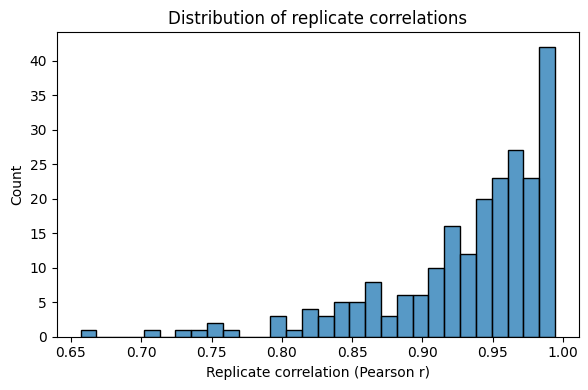

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.histplot(combined["mean_corr"], bins=30)

plt.xlabel("Replicate correlation (Pearson r)")
plt.ylabel("Count")
plt.title("Distribution of replicate correlations")

plt.tight_layout()
plt.savefig("replicate_correlation_distribution.png", dpi=300)

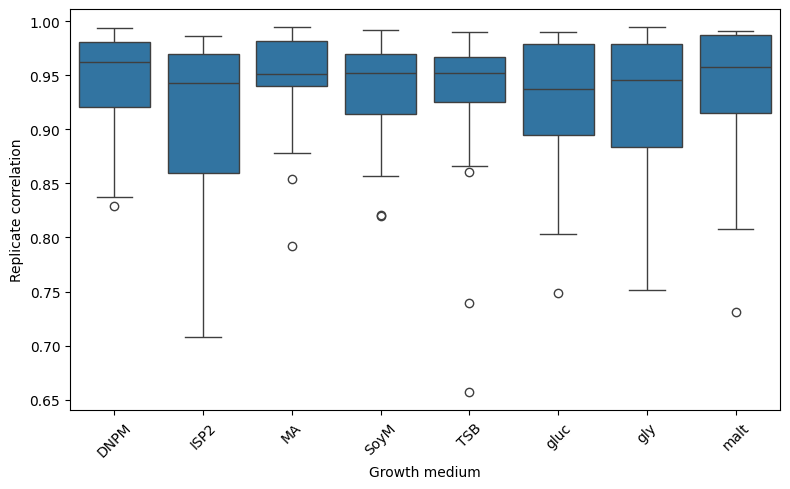

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(data=combined, x="media", y="mean_corr")

plt.xticks(rotation=45)
plt.ylabel("Replicate correlation")
plt.xlabel("Growth medium")

plt.tight_layout()
plt.savefig("replicate_correlation_per_media.png", dpi=300)

In [13]:
combined.head()

,Strain,media,replicates,mean_corr,min_corr,source_file
0,NBC_01392,DNPM,2,0.993165,0.993165,NBC_01392_replicate_quality.xlsx
1,NBC_01392,ISP2,2,0.936986,0.936986,NBC_01392_replicate_quality.xlsx
2,NBC_01392,MA,2,0.990489,0.990489,NBC_01392_replicate_quality.xlsx
3,NBC_01392,SoyM,2,0.989094,0.989094,NBC_01392_replicate_quality.xlsx
4,NBC_01392,TSB,2,0.989588,0.989588,NBC_01392_replicate_quality.xlsx


In [14]:
combined.to_excel('/Users/annasve/Desktop/article_data/input/metadata/replicate_correlation.xlsx', index = False)